In [ ]:
pip install "jupyter-ai[all]"


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
INFO: pip is looking at multiple versions of langchain-cohere to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-anthropic to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-anthropic to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If y

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.25.0 requires botocore<1.40.50,>=1.40.46, but you have botocore 1.42.69 which is incompatible.


# ClimateShield — Real Data Modeling Workflow

This notebook rebuilds the modeling flow around the **actual datasets in this repository** rather than the earlier synthetic demonstration path.

A few practical notes before diving in:

- the data is **small**, especially for impact modeling (9 annual records),
- so the goal here is **transparent analysis and a believable prototype**, not inflated certainty,
- the workflow follows a common notebook pattern used in public climate / hazard projects:
  **data audit → feature engineering → baseline model → stronger model → scenario checks**.

The notebook is meant to support the pitch deck and the analysis repo. It is not pretending to be a production forecasting system yet.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import LeaveOneOut, TimeSeriesSplit, cross_val_predict, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import joblib

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    # helpful when the notebook is opened from notebooks/
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT.resolve())
print("Raw data dir:", RAW_DIR.resolve())
print("Processed data dir:", PROC_DIR.resolve())

Project root: /
Raw data dir: /data/raw
Processed data dir: /data/processed


In [4]:
def load_csv(name: str) -> pd.DataFrame:
    path = RAW_DIR / name
    df = pd.read_csv(path)
    print(f"{name:<35} -> {df.shape}")
    return df

population = load_csv("durham_population.csv")
heat = load_csv("extreme_heat_days.csv")
temperature = load_csv("annual_temperature.csv")
impacts = load_csv("climate_impact_ontario.csv")
flood_risk = load_csv("flood_risk_infrastructure.csv")
funding = load_csv("municipal_climate_funding.csv")

manifest = json.loads((RAW_DIR / "manifest.json").read_text())
print("\nManifest generated at:", manifest.get("generated_at"))

durham_population.csv               -> (13, 4)
extreme_heat_days.csv               -> (40, 4)
annual_temperature.csv              -> (74, 3)
climate_impact_ontario.csv          -> (9, 6)
flood_risk_infrastructure.csv       -> (8, 5)
municipal_climate_funding.csv       -> (8, 5)

Manifest generated at: 2026-03-14T04:04:50.529053


### Method 1: Using the Files tab in Colab (Recommended for a few files)

1.  On the left sidebar of your Colab notebook, click the **'Files' icon** (it looks like a folder).
2.  This will open the file browser. At the top of the file browser pane, click the **'Upload to session storage' icon** (it looks like a file with an arrow pointing upwards).
3.  A file dialog will appear. Navigate to where you saved `durham_population.csv` on your local machine, select it, and click 'Open'.
4.  The file will be uploaded to the root of your Colab session storage (the `/content/` directory). From there, you might need to move it to `/data/raw/` if that's where your code expects it.
    You can move it by running the following Python command in a new code cell:
    ```python
    import shutil
    shutil.move('/content/durham_population.csv', '/data/raw/durham_population.csv')
    ```
    **Note**: Files uploaded this way are temporary and will be deleted when your Colab session ends.

### Method 2: Programmatic Upload (for specific cases or larger sets of files)

You can also upload files directly within a code cell using `google.colab.files`. This will prompt you to select a file from your local system.


In [3]:
from google.colab import files
import os

# Create the target directory if it doesn't exist
output_dir = '/data/raw/'
os.makedirs(output_dir, exist_ok=True)

print(f"Please upload 'durham_population.csv' (and other necessary CSVs) when prompted:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')
    # Move the uploaded file to the /data/raw directory
    if not os.path.exists(os.path.join(output_dir, filename)):
        os.rename(os.path.join('/content/', filename), os.path.join(output_dir, filename))
    else:
        print(f"File {filename} already exists in {output_dir}. Skipping move.")

print("Files are now in the '/data/raw/' directory.")

Please upload 'durham_population.csv' (and other necessary CSVs) when prompted:


Saving annual_temperature.csv to annual_temperature.csv
Saving climate_impact_ontario.csv to climate_impact_ontario.csv
Saving durham_population.csv to durham_population.csv
Saving extreme_heat_days.csv to extreme_heat_days.csv
Saving flood_risk_infrastructure.csv to flood_risk_infrastructure.csv
Saving manifest.json to manifest.json
Saving municipal_climate_funding.csv to municipal_climate_funding.csv
Uploaded file: annual_temperature.csv
Uploaded file: climate_impact_ontario.csv
Uploaded file: durham_population.csv
Uploaded file: extreme_heat_days.csv
Uploaded file: flood_risk_infrastructure.csv
Uploaded file: manifest.json
Uploaded file: municipal_climate_funding.csv
Files are now in the '/data/raw/' directory.


After uploading, please ensure that all the required CSV files mentioned in your `load_csv` function (e.g., `durham_population.csv`, `extreme_heat_days.csv`, etc.) are present in the `/data/raw/` directory. You can check the contents of the directory by running `!ls /data/raw/` in a code cell.

## data audit

In [6]:
datasets = {
    "population": population,
    "heat": heat,
    "temperature": temperature,
    "impacts": impacts,
    "flood_risk": flood_risk,
    "funding": funding,
}

audit_rows = []
for name, df in datasets.items():
    audit_rows.append({
        "dataset": name,
        "rows": len(df),
        "cols": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "year_min": df["year"].min() if "year" in df.columns else np.nan,
        "year_max": df["year"].max() if "year" in df.columns else np.nan,
    })

audit = pd.DataFrame(audit_rows).sort_values("dataset")
audit

,dataset,rows,cols,missing_cells,year_min,year_max
4,flood_risk,8,5,5,NaN,NaN
5,funding,8,5,0,2018.0,2025.0
1,heat,40,4,0,1990.0,2050.0
3,impacts,9,6,0,2015.0,2023.0
0,population,13,4,0,1991.0,2051.0
2,temperature,74,3,0,1950.0,2023.0


In [7]:
for name, df in datasets.items():
    print(f"\n--- {name.upper()} ---")
    display(df.head())


--- POPULATION ---


,year,population,is_projection,source
0,1991,458616,False,Statistics Canada Census
1,1996,485993,False,Statistics Canada Census
2,2001,506901,False,Statistics Canada Census
3,2006,561258,False,Statistics Canada Census
4,2011,608124,False,Statistics Canada Census



--- HEAT ---


,year,extreme_heat_days,data_type,source
0,1990,5,historical,ECCC Station 6156732 (Oshawa)
1,1991,7,historical,ECCC Station 6156732 (Oshawa)
2,1992,4,historical,ECCC Station 6156732 (Oshawa)
3,1993,9,historical,ECCC Station 6156732 (Oshawa)
4,1994,6,historical,ECCC Station 6156732 (Oshawa)



--- TEMPERATURE ---


...

,year,insured_losses_m_cad,heat_hospitalizations_ontario,flood_events_durham,avg_response_time_hrs,source
0,2015,1200,312,3,5.2,IBC Severe Weather Report + Public Safety Cana...
1,2016,980,287,2,4.8,IBC Severe Weather Report + Public Safety Cana...
2,2017,1850,445,4,6.1,IBC Severe Weather Report + Public Safety Cana...
3,2018,2100,398,5,5.9,IBC Severe Weather Report + Public Safety Cana...
4,2019,1650,521,3,5.5,IBC Severe Weather Report + Public Safety Cana...



--- FLOOD_RISK ---


,infrastructure_category,pct_at_risk,estimated_replacement_value_m_cad,current_monitoring,source
0,Roads & Bridges,38,4200,Partial,GEI Consultants 2022 + TRCA Flood Ready Durham
1,Stormwater Drains,52,890,NaN,GEI Consultants 2022 + TRCA Flood Ready Durham
2,Electrical Substations,29,650,Partial,GEI Consultants 2022 + TRCA Flood Ready Durham
3,Agricultural Land,80,1100,NaN,GEI Consultants 2022 + TRCA Flood Ready Durham
4,Residential Zones,44,8500,NaN,GEI Consultants 2022 + TRCA Flood Ready Durham



--- FUNDING ---


,year,fcm_gmf_disbursed_m_cad,infra_canada_climate_m_cad,num_municipalities_funded,source
0,2018,89,120,142,FCM Annual Report + Infrastructure Canada
1,2019,112,145,178,FCM Annual Report + Infrastructure Canada
2,2020,134,198,203,FCM Annual Report + Infrastructure Canada
3,2021,178,312,267,FCM Annual Report + Infrastructure Canada
4,2022,215,445,334,FCM Annual Report + Infrastructure Canada


## Rebuild a few clean feature tables from the raw data

In [8]:
heat_hist = heat.loc[heat["data_type"].eq("historical")].copy()
heat_hist = heat_hist.merge(
    temperature[["year", "mean_temp_c"]],
    on="year",
    how="left",
)
heat_hist = heat_hist.sort_values("year").reset_index(drop=True)

baseline_temp = heat_hist.loc[heat_hist["year"].between(1990, 2000), "mean_temp_c"].mean()

heat_hist["heat_days_lag1"] = heat_hist["extreme_heat_days"].shift(1)
heat_hist["heat_days_lag2"] = heat_hist["extreme_heat_days"].shift(2)
heat_hist["heat_rolling_3"] = heat_hist["extreme_heat_days"].rolling(3, min_periods=2).mean()
heat_hist["heat_rolling_5"] = heat_hist["extreme_heat_days"].rolling(5, min_periods=3).mean()
heat_hist["temp_anomaly"] = heat_hist["mean_temp_c"] - baseline_temp
heat_hist["yoy_change"] = heat_hist["extreme_heat_days"].diff()
heat_hist["high_heat_year"] = (heat_hist["extreme_heat_days"] >= heat_hist["extreme_heat_days"].median()).astype(int)

heat_hist.tail()

,year,extreme_heat_days,data_type,source,mean_temp_c,heat_days_lag1,heat_days_lag2,heat_rolling_3,heat_rolling_5,temp_anomaly,yoy_change,high_heat_year
29,2019,21,historical,ECCC Station 6156732 (Oshawa),8.49,17.0,20.0,19.333333,18.6,0.370909,4.0,1
30,2020,14,historical,ECCC Station 6156732 (Oshawa),8.87,21.0,17.0,17.333333,17.6,0.750909,-7.0,1
31,2021,18,historical,ECCC Station 6156732 (Oshawa),9.30,14.0,21.0,17.666667,18.0,1.180909,4.0,1
32,2022,22,historical,ECCC Station 6156732 (Oshawa),8.77,18.0,14.0,18.000000,18.4,0.650909,4.0,1
33,2023,19,historical,ECCC Station 6156732 (Oshawa),9.35,22.0,18.0,19.666667,18.8,1.230909,-3.0,1


In [9]:
impact_features = impacts.merge(
    heat_hist[["year", "extreme_heat_days", "heat_days_lag1", "heat_days_lag2", "heat_rolling_3", "temp_anomaly"]],
    on="year",
    how="left",
)

impact_features["cumulative_losses_m"] = impact_features["insured_losses_m_cad"].cumsum()
impact_features["loss_per_flood_event"] = (
    impact_features["insured_losses_m_cad"] / impact_features["flood_events_durham"].replace(0, np.nan)
)
impact_features["hospitalisations_per_heat_day"] = (
    impact_features["heat_hospitalizations_ontario"] / impact_features["extreme_heat_days"].replace(0, np.nan)
)
impact_features["high_strain_year"] = (
    (impact_features["flood_events_durham"] >= 4)
    | (impact_features["avg_response_time_hrs"] >= 6.0)
    | (impact_features["heat_hospitalizations_ontario"] >= impact_features["heat_hospitalizations_ontario"].median())
).astype(int)

impact_features

,year,insured_losses_m_cad,heat_hospitalizations_ontario,flood_events_durham,avg_response_time_hrs,source,extreme_heat_days,heat_days_lag1,heat_days_lag2,heat_rolling_3,temp_anomaly,cumulative_losses_m,loss_per_flood_event,hospitalisations_per_heat_day,high_strain_year
0,2015,1200,312,3,5.2,IBC Severe Weather Report + Public Safety Cana...,19,15.0,18.0,17.333333,0.980909,1200,400.000000,16.421053,0
1,2016,980,287,2,4.8,IBC Severe Weather Report + Public Safety Cana...,16,19.0,15.0,16.666667,0.510909,2180,490.000000,17.937500,0
2,2017,1850,445,4,6.1,IBC Severe Weather Report + Public Safety Cana...,20,16.0,19.0,18.333333,0.910909,4030,462.500000,22.250000,1
3,2018,2100,398,5,5.9,IBC Severe Weather Report + Public Safety Cana...,17,20.0,16.0,17.666667,0.700909,6130,420.000000,23.411765,1
4,2019,1650,521,3,5.5,IBC Severe Weather Report + Public Safety Cana...,21,17.0,20.0,19.333333,0.370909,7780,550.000000,24.809524,1
5,2020,2400,634,6,6.8,IBC Severe Weather Report + Public Safety Cana...,14,21.0,17.0,17.333333,0.750909,10180,400.000000,45.285714,1
6,2021,3100,712,7,7.2,IBC Severe Weather Report + Public Safety Cana...,18,14.0,21.0,17.666667,1.180909,13280,442.857143,39.555556,1
7,2022,2800,689,5,6.5,IBC Severe Weather Report + Public Safety Cana...,22,18.0,14.0,18.000000,0.650909,16080,560.000000,31.318182,1
8,2023,3450,823,8,7.8,IBC Severe Weather Report + Public Safety Cana...,19,22.0,18.0,19.666667,1.230909,19530,431.250000,43.315789,1


## Basic EDA

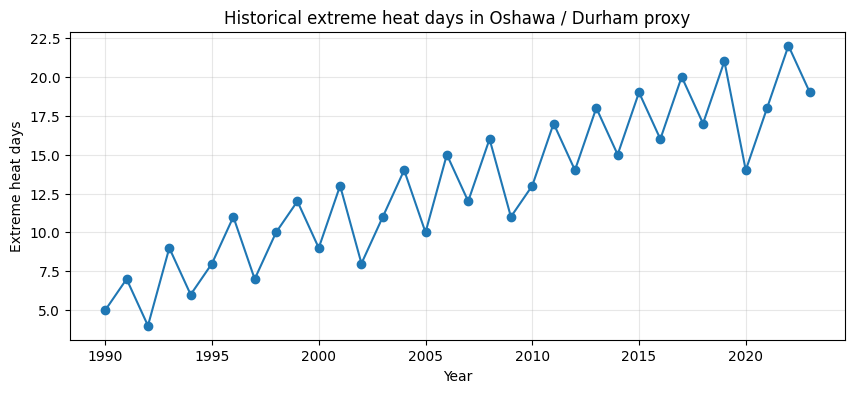

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(heat_hist["year"], heat_hist["extreme_heat_days"], marker="o")
ax.set_title("Historical extreme heat days in Oshawa / Durham proxy")
ax.set_xlabel("Year")
ax.set_ylabel("Extreme heat days")
ax.grid(alpha=0.3)
plt.show()

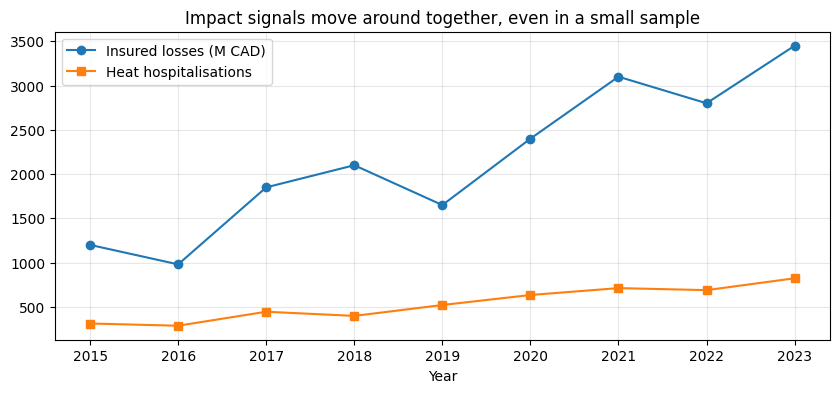

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(impact_features["year"], impact_features["insured_losses_m_cad"], marker="o", label="Insured losses (M CAD)")
ax.plot(impact_features["year"], impact_features["heat_hospitalizations_ontario"], marker="s", label="Heat hospitalisations")
ax.set_title("Impact signals move around together, even in a small sample")
ax.set_xlabel("Year")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [12]:
corr_cols = [
    "extreme_heat_days",
    "heat_days_lag1",
    "heat_days_lag2",
    "insured_losses_m_cad",
    "flood_events_durham",
    "avg_response_time_hrs",
    "heat_hospitalizations_ontario",
]
impact_features[corr_cols].corr().round(2)

,extreme_heat_days,heat_days_lag1,heat_days_lag2,insured_losses_m_cad,flood_events_durham,avg_response_time_hrs,heat_hospitalizations_ontario
extreme_heat_days,1.00,-0.40,0.13,0.13,-0.10,0.01,0.18
heat_days_lag1,-0.40,1.00,-0.52,0.26,0.32,0.29,0.26
heat_days_lag2,0.13,-0.52,1.00,0.15,0.22,0.25,0.21
insured_losses_m_cad,0.13,0.26,0.15,1.00,0.96,0.97,0.95
flood_events_durham,-0.10,0.32,0.22,0.96,1.00,0.98,0.87
avg_response_time_hrs,0.01,0.29,0.25,0.97,0.98,1.00,0.93
heat_hospitalizations_ontario,0.18,0.26,0.21,0.95,0.87,0.93,1.00


## Model A- heat-day projection

This is the cleanest modeling task in the repo because the historical series is longer than the annual impact table.
We compare a plain linear baseline against a small polynomial model and score them with time-series cross-validation.

In [13]:
heat_model_df = heat_hist.dropna(subset=["extreme_heat_days"]).copy()
X_heat = heat_model_df[["year"]].values
y_heat = heat_model_df["extreme_heat_days"].values

tscv = TimeSeriesSplit(n_splits=5)

linear_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("reg", LinearRegression()),
])

poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("reg", LinearRegression()),
])

scores = {}
for name, model in {"linear": linear_pipe, "poly_deg2": poly_pipe}.items():
    cv_scores = cross_val_score(model, X_heat, y_heat, cv=tscv, scoring="r2")
    scores[name] = {
        "cv_r2_mean": float(np.mean(cv_scores)),
        "cv_r2_std": float(np.std(cv_scores)),
        "fold_scores": np.round(cv_scores, 3).tolist(),
    }

pd.DataFrame(scores).T

,cv_r2_mean,cv_r2_std,fold_scores
linear,-0.030011,0.253216,"[-0.508, 0.064, 0.2, 0.143, -0.05]"
poly_deg2,-0.448514,0.94053,"[-0.231, -2.305, 0.206, 0.128, -0.04]"


In [18]:
best_heat_model = poly_pipe
best_heat_model.fit(X_heat, y_heat)

heat_train_pred = best_heat_model.predict(X_heat)

heat_metrics = {
    "r2_train": r2_score(y_heat, heat_train_pred),
    "rmse_train": np.sqrt(mean_squared_error(y_heat, heat_train_pred)),
    "mae_train": mean_absolute_error(y_heat, heat_train_pred),
}
heat_metrics

{'r2_train': 0.8102366646835698,
 'rmse_train': np.float64(2.055446592091432),
 'mae_train': 1.8385756976587448}

In [19]:
future_years = pd.DataFrame({"year": np.arange(2024, 2051)})
future_years["predicted_extreme_heat_days"] = best_heat_model.predict(future_years[["year"]])

residual_std = np.std(y_heat - heat_train_pred)
future_years["lower_90"] = future_years["predicted_extreme_heat_days"] - 1.645 * residual_std
future_years["upper_90"] = future_years["predicted_extreme_heat_days"] + 1.645 * residual_std

future_years.head()

,year,predicted_extreme_heat_days,lower_90,upper_90
0,2024,20.108957,16.727748,23.490167
1,2025,20.467590,17.086380,23.848799
2,2026,20.822116,17.440906,24.203326
3,2027,21.172536,17.791327,24.553746
4,2028,21.518850,18.137641,24.900060


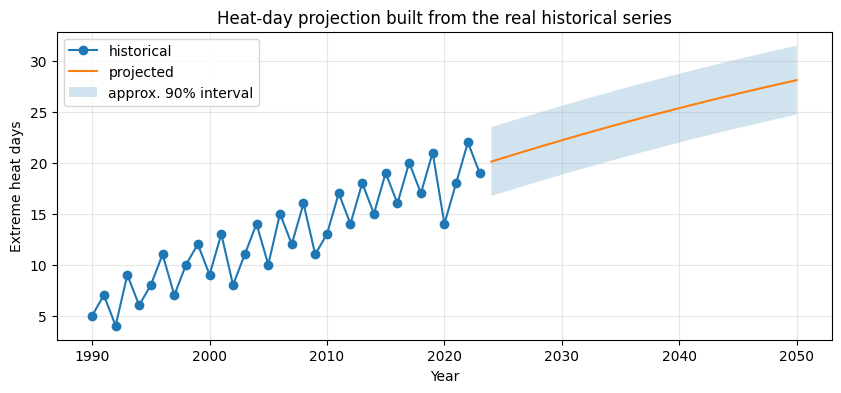

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(heat_model_df["year"], y_heat, marker="o", label="historical")
ax.plot(future_years["year"], future_years["predicted_extreme_heat_days"], label="projected")
ax.fill_between(
    future_years["year"],
    future_years["lower_90"],
    future_years["upper_90"],
    alpha=0.2,
    label="approx. 90% interval",
)
ax.set_title("Heat-day projection built from the real historical series")
ax.set_xlabel("Year")
ax.set_ylabel("Extreme heat days")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Model B- high-strain year classifier

The impact table is tiny, so instead of pretending we can train a flashy deep model, we turn this into a small operational question:

**Can we classify whether a year looks like a high-strain year for the system?**

The target is a simple rule-based label:
- flood events are elevated, **or**
- response times are elevated, **or**
- heat hospitalisations are unusually high.

This is the kind of framing a real prototype team might use while waiting for richer municipal data.

In [21]:
clf_df = impact_features.copy()

feature_cols = [
    "extreme_heat_days",
    "heat_days_lag1",
    "heat_days_lag2",
    "insured_losses_m_cad",
    "loss_per_flood_event",
    "avg_response_time_hrs",
    "temp_anomaly",
]

X_clf = clf_df[feature_cols]
y_clf = clf_df["high_strain_year"]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), feature_cols)
    ]
)

baseline_clf = Pipeline([
    ("prep", pre),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

forest_clf = Pipeline([
    ("prep", pre),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=1,
        random_state=42
    )),
])

loo = LeaveOneOut()

clf_rows = []
for name, model in {"log_reg": baseline_clf, "rf_clf": forest_clf}.items():
    preds = cross_val_predict(model, X_clf, y_clf, cv=loo)
    clf_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_clf, preds),
        "pred_positive": int(preds.sum()),
    })

pd.DataFrame(clf_rows)

,model,accuracy,pred_positive
0,log_reg,0.888889,8
1,rf_clf,0.666667,8


In [22]:
forest_clf.fit(X_clf, y_clf)
clf_pred = forest_clf.predict(X_clf)

print(classification_report(y_clf, clf_pred, digits=3))
print("Confusion matrix\n", confusion_matrix(y_clf, clf_pred))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000         2
           1      1.000     1.000     1.000         7

    accuracy                          1.000         9
   macro avg      1.000     1.000     1.000         9
weighted avg      1.000     1.000     1.000         9

Confusion matrix
 [[2 0]
 [0 7]]


## Model C- hospitalisation regression

This is still a small-sample exercise. The point here is not to declare victory, but to compare a regularized baseline with a nonlinear tree ensemble and then reuse the better-behaved model for scenario scoring.

In [24]:
reg_df = impact_features.dropna(subset=["heat_days_lag1", "heat_days_lag2"]).copy()

reg_features = [
    "extreme_heat_days",
    "heat_days_lag1",
    "heat_days_lag2",
    "insured_losses_m_cad",
    "flood_events_durham",
    "avg_response_time_hrs",
]

X_reg = reg_df[reg_features]
y_reg = reg_df["heat_hospitalizations_ontario"]

reg_pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), reg_features)
    ]
)

ridge_reg = Pipeline([
    ("prep", reg_pre),
    ("model", Ridge(alpha=1.0)),
])

rf_reg = Pipeline([
    ("prep", reg_pre),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=1,
        random_state=42
    )),
])

tscv_small = TimeSeriesSplit(n_splits=3)

reg_rows = []
for name, model in {"ridge": ridge_reg, "rf_reg": rf_reg}.items():
    all_preds = []
    all_y_true = []

    # Manually iterate through the splits to get predictions for test sets
    for train_idx, test_idx in tscv_small.split(X_reg, y_reg):
        X_train, X_test = X_reg.iloc[train_idx], X_reg.iloc[test_idx]
        y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        all_preds.extend(y_pred)
        all_y_true.extend(y_test)

    reg_rows.append({
        "model": name,
        "r2_cv_like": r2_score(all_y_true, all_preds),
        "rmse_cv_like": np.sqrt(mean_squared_error(all_y_true, all_preds)), # Calculate RMSE by taking sqrt of MSE
        "mae_cv_like": mean_absolute_error(all_y_true, all_preds),
    })

pd.DataFrame(reg_rows)

,model,r2_cv_like,rmse_cv_like,mae_cv_like
0,ridge,-1.081021,198.123024,178.162342
1,rf_reg,-1.126382,200.270697,183.572778


In [25]:
chosen_reg = ridge_reg
chosen_reg.fit(X_reg, y_reg)

reg_df["pred_hospitalisations"] = chosen_reg.predict(X_reg)
reg_df["pred_with_alerts_20pct_lower"] = reg_df["pred_hospitalisations"] * 0.80
reg_df["avoided_hospitalisations_est"] = (
    reg_df["pred_hospitalisations"] - reg_df["pred_with_alerts_20pct_lower"]
).round(0)

reg_df[[
    "year",
    "heat_hospitalizations_ontario",
    "pred_hospitalisations",
    "pred_with_alerts_20pct_lower",
    "avoided_hospitalisations_est",
]]

,year,heat_hospitalizations_ontario,pred_hospitalisations,pred_with_alerts_20pct_lower,avoided_hospitalisations_est
0,2015,312,347.750218,278.200174,70.0
1,2016,287,270.547880,216.438304,54.0
2,2017,445,503.544026,402.835221,101.0
3,2018,398,499.338549,399.470840,100.0
4,2019,521,457.949013,366.359210,92.0
5,2020,634,576.956119,461.564895,115.0
6,2021,712,694.279887,555.423910,139.0
7,2022,689,640.535630,512.428504,128.0
8,2023,823,830.098678,664.078942,166.0


## Scenario slice for the pitch

This is where the notebook becomes useful for the deck:
- use the projected heat days from the longer heat series,
- combine them with a simple planning assumption,
- turn them into an operational story instead of a naked metric.

In [26]:
scenario_years = future_years.query("year in [2024, 2030, 2040, 2050]").copy()
latest_losses = impacts["insured_losses_m_cad"].mean()
latest_flood_events = impacts["flood_events_durham"].median()
latest_response = impacts["avg_response_time_hrs"].median()

scenario_rows = []
for _, row in scenario_years.iterrows():
    synthetic_row = pd.DataFrame([{
        "extreme_heat_days": row["predicted_extreme_heat_days"],
        "heat_days_lag1": heat_hist["extreme_heat_days"].iloc[-1],
        "heat_days_lag2": heat_hist["extreme_heat_days"].iloc[-2],
        "insured_losses_m_cad": latest_losses,
        "flood_events_durham": latest_flood_events,
        "avg_response_time_hrs": latest_response,
    }])
    pred_hosp = float(chosen_reg.predict(synthetic_row)[0])
    scenario_rows.append({
        "year": int(row["year"]),
        "projected_heat_days": round(float(row["predicted_extreme_heat_days"]), 1),
        "estimated_hospitalisations_status_quo": round(pred_hosp, 1),
        "estimated_hospitalisations_with_alerts": round(pred_hosp * 0.80, 1),
        "avoided_hospitalisations_est": round(pred_hosp * 0.20, 1),
    })

scenario_df = pd.DataFrame(scenario_rows)
scenario_df

,year,projected_heat_days,estimated_hospitalisations_status_quo,estimated_hospitalisations_with_alerts,avoided_hospitalisations_est
0,2024,20.1,578.0,462.4,115.6
1,2030,22.2,601.7,481.4,120.3
2,2040,25.4,637.5,510.0,127.5
3,2050,28.1,668.7,535.0,133.7


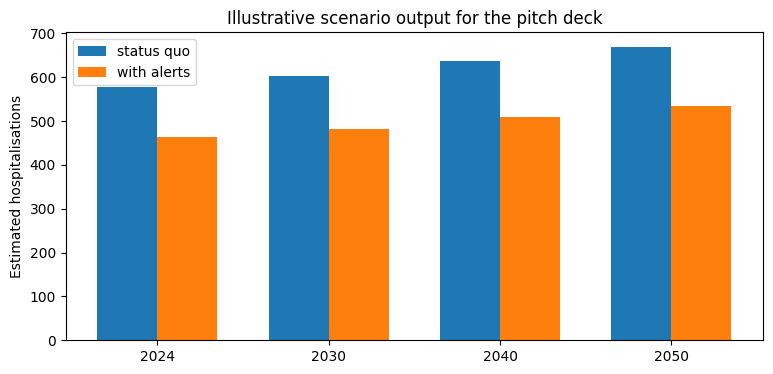

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
width = 0.35
x = np.arange(len(scenario_df))

ax.bar(x - width/2, scenario_df["estimated_hospitalisations_status_quo"], width, label="status quo")
ax.bar(x + width/2, scenario_df["estimated_hospitalisations_with_alerts"], width, label="with alerts")
ax.set_xticks(x)
ax.set_xticklabels(scenario_df["year"].astype(str))
ax.set_title("Illustrative scenario output for the pitch deck")
ax.set_ylabel("Estimated hospitalisations")
ax.legend()
plt.show()

## Save artifacts for the repo

In [28]:
heat_projection_path = MODEL_DIR / "realdata_heat_projection_model.joblib"
high_strain_path = MODEL_DIR / "realdata_high_strain_classifier.joblib"
hospitalisation_path = MODEL_DIR / "realdata_hospitalisation_model.joblib"
scenario_path = MODEL_DIR / "realdata_scenario_table.csv"

joblib.dump(best_heat_model, heat_projection_path)
joblib.dump(forest_clf, high_strain_path)
joblib.dump(chosen_reg, hospitalisation_path)
scenario_df.to_csv(scenario_path, index=False)

saved = pd.DataFrame({
    "artifact": [
        heat_projection_path.name,
        high_strain_path.name,
        hospitalisation_path.name,
        scenario_path.name,
    ],
    "location": [str(heat_projection_path), str(high_strain_path), str(hospitalisation_path), str(scenario_path)]
})
saved

,artifact,location
0,realdata_heat_projection_model.joblib,/outputs/models/realdata_heat_projection_model...
1,realdata_high_strain_classifier.joblib,/outputs/models/realdata_high_strain_classifie...
2,realdata_hospitalisation_model.joblib,/outputs/models/realdata_hospitalisation_model...
3,realdata_scenario_table.csv,/outputs/models/realdata_scenario_table.csv


## Is this 'production ready'?

A fair answer would be:

> Not yet. This notebook is a credible prototype built on real Durham-relevant and Ontario climate-impact data. It is useful for demonstrating trend direction, feature logic, and planning scenarios. The next step is integrating richer local operational data streams, especially sensor, response, and infrastructure telemetry and, so the models can be retrained at a finer temporal and spatial resolution.